In [1]:
import numpy as np
import pandas as pd
from math import e
import matplotlib.pyplot as plt

# seed고정
np.random.seed(42)

In [2]:
# 온도, 습도, 정답 데이터
# 가운데 구간만 1이기때문에 선형 직선으로 표시하기 어려움
data = {
    'temperature': [10, 15, 20, 25, 30, 35],
    'humidity':    [30, 40, 50, 60, 70, 80],
    'y':           [ 0,  0,  1,  1,  1,  0]
}

df = pd.DataFrame(data)
df

,temperature,humidity,y
0,10,30,0
1,15,40,0
2,20,50,1
3,25,60,1
4,30,70,1
5,35,80,0


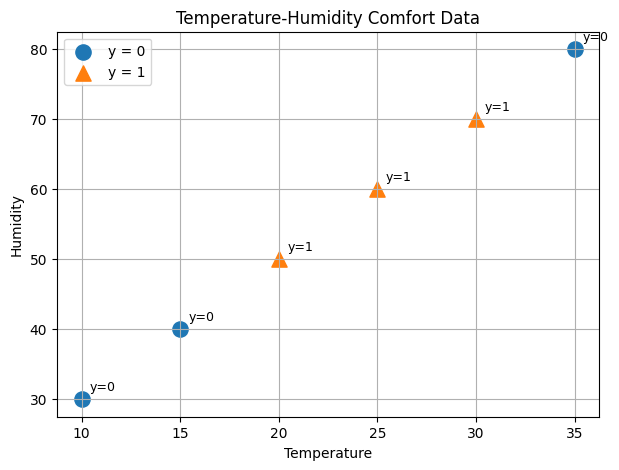

In [3]:
plt.figure(figsize=(7, 5))

# y=0, y=1점 나눠서 서로 다른 marker로 그림
# boolean indexing
mask0 = df['y'] == 0 # 쾌적하지 않은 행
mask1 = df['y'] == 1 # 쾌적한 행
plt.scatter(df.loc[mask0, 'temperature'], df.loc[mask0, 'humidity'], marker='o', s=120, label='y = 0')
plt.scatter(df.loc[mask1, 'temperature'], df.loc[mask1, 'humidity'], marker='^', s=120, label='y = 1')

# 각 점 옆에 y 값을 작게 표시
for temp, hum, yv in zip(df['temperature'], df['humidity'], df['y']):
    plt.annotate(f'y={yv}', (temp, hum), textcoords='offset points', xytext=(6, 6), fontsize=9)

plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.title('Temperature-Humidity Comfort Data')
plt.legend()
plt.grid(True)

In [4]:
# X_raw: 원본 입력값. (행의 수, 2) 모양으로 만들기
X_raw = df[['temperature', 'humidity']].to_numpy(dtype=float)

# y: 실제 정답 (n, 1) 모양의 세로 벡터
y = df['y'].to_numpy(dtype=float).reshape(-1, 1)

# x_mean: 온도, 습도의 평균
# axis=0은 열 방향으로 계산. 컬럼별 평균
# keepdims=True로 (1,2)모양 유지. 브로드캐스팅이 쉽게 되도록
X_mean = X_raw.mean(axis=0, keepdims=True)
# 표준편차
X_std = X_raw.std(axis=0, keepdims=True)

# 정규화
# 온도와 습도처럼 범위가 다른 값을 그대로 넣으면 불안정하기 때문
X_norm = (X_raw - X_mean) / X_std
X_mean, X_std, X_norm.shape, y.shape

(array([[22.5, 55. ]]), array([[ 8.53912564, 17.07825128]]), (6, 2), (6, 1))

In [5]:
# 데이터 프레임에 새 컬럼으로 추가
df['temperature_norm'] = X_norm[:, 0]
df['humidity_norm'] = X_norm[:, 1]
df

,temperature,humidity,y,temperature_norm,humidity_norm
0,10,30,0,-1.46385,-1.46385
1,15,40,0,-0.87831,-0.87831
2,20,50,1,-0.29277,-0.29277
3,25,60,1,0.29277,0.29277
4,30,70,1,0.87831,0.87831
5,35,80,0,1.46385,1.46385


In [6]:
def sigmoid(H):
    # H값 범위제한. exp계산에서 값이 너무 커질수 있기때문
    H_clip = np.clip(H, -500, 500)
    
    z = 1.0 / (1.0 + e ** (-H_clip))
    return z

print(sigmoid(0), sigmoid(10), sigmoid(-10))

0.5 0.9999546021312976 4.539786870243442e-05


In [7]:
def bce_cost(y, z):
    epsilon = 1e-7
    # 시그모이드 결과 확률 범위 지정. log 계산 안정화
    z_clip = np.clip(z, epsilon, 1-epsilon)

    # bce 계산
    cost = -(y * np.log(z_clip) + (1 - y) * np.log(1 - z_clip))

    return np.mean(cost)

y_test = np.array([[1], [0]])
z_good = np.array([[0.9], [0.1]])
z_bad = np.array([[0.1], [0.9]])
print('잘 맞춘 경우의 Cost:', bce_cost(y_test, z_good))
print('크게 틀린 경우의 Cost:', bce_cost(y_test, z_bad))

잘 맞춘 경우의 Cost: 0.10536051565782628
크게 틀린 경우의 Cost: 2.302585092994046


In [8]:
# 입력값 미리 세로 벡터로 꺼내놓기
# X_norm[:, 0] -> shape가 (n,)인 1차원 배열
# X_norm[:, [0]] -> shape가 (n,1)인 2차원 배열
# y가 (n,1)모양 이므로 []씌움
X1_norm = X_norm[:, [0]]
X2_norm = X_norm[:, [1]]
X1_norm, X2_norm

(array([[-1.46385011],
        [-0.87831007],
        [-0.29277002],
        [ 0.29277002],
        [ 0.87831007],
        [ 1.46385011]]),
 array([[-1.46385011],
        [-0.87831007],
        [-0.29277002],
        [ 0.29277002],
        [ 0.87831007],
        [ 1.46385011]]))

In [9]:
# 학습할 파라미터 초기값
a1 = 0.0
a2 = 0.0
b = 0.0
learning_rate = 0.1
epochs = 10000
cost_history = []

In [10]:
# 학습 시작
for epoch in range(epochs):
    # 순전파 (선형 출력 계산)
    H = a1 * X1_norm + a2 * X2_norm + b
    z = sigmoid(H)
    cost = bce_cost(y, z)
    cost_history.append(cost)

    # gradient 계산
    grad_a1 = np.mean((z - y) * X1_norm) # a1 편미분값(gradient)
    grad_a2 = np.mean((z - y) * X2_norm)
    grad_b = np.mean(z - y)

    # update
    a1 = a1 - learning_rate * grad_a1
    a2 = a2 - learning_rate * grad_a2
    b = b - learning_rate * grad_b

    if epoch % 100 == 0:
        print(f'epoch {epoch:5d} | cost={cost:.6f} | a1={a1:.4f} | a2={a2:.4f} | b={b:.4f}')

epoch     0 | cost=0.693147 | a1=0.0146 | a2=0.0146 | b=0.0000
epoch   100 | cost=0.649174 | a1=0.3052 | a2=0.3052 | b=0.0000
epoch   200 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=0.0000
epoch   300 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=0.0000
epoch   400 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=0.0000
epoch   500 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=0.0000
epoch   600 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=0.0000
epoch   700 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=0.0000
epoch   800 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=-0.0000
epoch   900 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=-0.0000
epoch  1000 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=-0.0000
epoch  1100 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=-0.0000
epoch  1200 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=-0.0000
epoch  1300 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=-0.0000
epoch  1400 | cost=0.649169 | a1=0.3085 | a2=0.3085 | b=-0.0000
epoch  1500 | cost=0.649169 | a1=0.3085 | a2=0.3

In [11]:
# 마지막 상태 출력
print('-' * 60)
print(f'학습 종료 | 최종 cost={cost_history[-1]:.6f}')
print(f'학습된 파라미터: a1={a1:.4f}, a2={a2:.4f}, b={b:.4f}')

------------------------------------------------------------
학습 종료 | 최종 cost=0.649169
학습된 파라미터: a1=0.3085, a2=0.3085, b=-0.0000


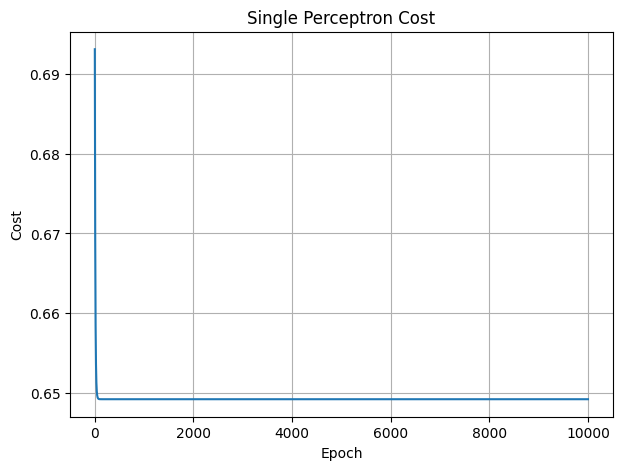

In [12]:
plt.figure(figsize=(7, 5))
# x축: epoch 번호, y축: 그 때의 Cost

plt.plot(range(len(cost_history)), cost_history)

plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Single Perceptron Cost')
plt.grid(True)


In [13]:
# 학습 끝난 파라미터로 최종 순전파 다시 계산
H_final = a1 * X1_norm + a2 * X2_norm + b
z_final = sigmoid(H_final)

pred = (z_final >= 0.5).astype(int)

# ravel(): (n, 1) 세로 벡터를 1차원으로 펼치는 역할
result_df = pd.DataFrame({
    'temperature': df['temperature'],
    'humidity': df['humidity'],
    'y_actual': y.astype(int).ravel(),
    'H': np.round(H_final.ravel(), 4),
    'z_probability': np.round(z_final.ravel(), 4),
    'single_perceptron_pred': pred.ravel()
})
# 실제 정답과 예측결과가 같은지 확인
result_df['is_correct'] = result_df['y_actual'] == result_df['single_perceptron_pred']
result_df

,temperature,humidity,y_actual,H,z_probability,single_perceptron_pred,is_correct
0,10,30,0,-0.9033,0.2884,0,True
1,15,40,0,-0.5420,0.3677,0,True
2,20,50,1,-0.1807,0.4550,0,False
3,25,60,1,0.1807,0.5450,1,True
4,30,70,1,0.5420,0.6323,1,True
5,35,80,0,0.9033,0.7116,1,False


In [14]:
# 오답 행 골라내기
wrong_df = result_df[result_df['is_correct'] == False]
n_wrong = len(wrong_df)

if n_wrong > 0:
    print(f'단일 퍼셉트론이 틀린 데이터: 총 {n_wrong}개')
    print('-' * 60)
    display(wrong_df)

    wrong_temps = wrong_df['temperature'].tolist()
    print('-' * 60)
    print(f'[자동 해석] 오답이 발생한 구간(온도 기준): {wrong_temps}')
    print('이 구간을 틀리는 이유는 "학습을 덜 해서" 가 아니라,')
    print("단일 퍼셉트론이 만들 수 있는 판단 경계가 'H = 0 직선 하나' 뿐이기 때문입니다.")
    print('직선 하나로는 가운데(1)를 양쪽(0)에서 동시에 떼어낼 수 없어, 위 구간에서 오답이 생깁니다.')
else:
    # 오답이 없어도 결정경계는 여전히 하나
    print('모든 데이터를 맞췄지만 결정 경계는 여전히 직선 하나라는 한계가 그대로 남아 있습니다.')
    print('구조적 한계가 사라진 것은 아니며, 이 한계는 아래 결정 경계 시각화에서 다시 확인합니다.')

단일 퍼셉트론이 틀린 데이터: 총 2개
------------------------------------------------------------


,temperature,humidity,y_actual,H,z_probability,single_perceptron_pred,is_correct
2,20,50,1,-0.1807,0.4550,0,False
5,35,80,0,0.9033,0.7116,1,False


------------------------------------------------------------
[자동 해석] 오답이 발생한 구간(온도 기준): [20, 35]
이 구간을 틀리는 이유는 "학습을 덜 해서" 가 아니라,
단일 퍼셉트론이 만들 수 있는 판단 경계가 'H = 0 직선 하나' 뿐이기 때문입니다.
직선 하나로는 가운데(1)를 양쪽(0)에서 동시에 떼어낼 수 없어, 위 구간에서 오답이 생깁니다.


In [15]:
# 단일 퍼셉트론 예측결과를 원본 그래프 위에 표시

# 실제 정답 기준으로 데이터 나누기
mask0 = df['y'] == 0
mask1 = df['y'] == 1
mask0

0     True
1     True
2    False
3    False
4    False
5     True
Name: y, dtype: bool

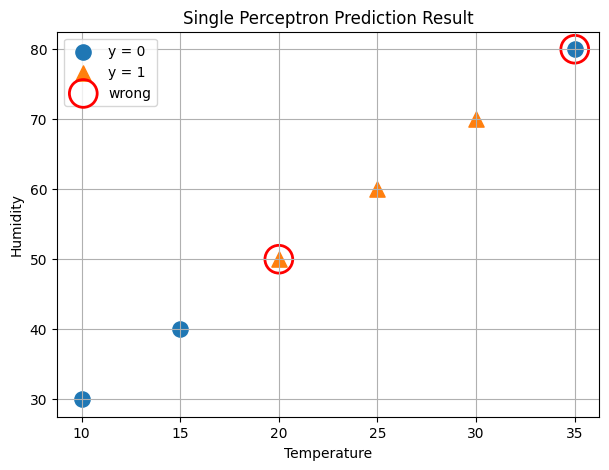

In [16]:

# 동그라미: 실제정답 y = 0
# 세모: 실제정답 y = 1
plt.figure(figsize=(7, 5))
plt.scatter(
    df.loc[mask0, 'temperature'], df.loc[mask0, 'humidity'], marker='o', s=120, label='y = 0'
)

plt.scatter(
    df.loc[mask1, 'temperature'], df.loc[mask1, 'humidity'], marker='^', s=120, label='y = 1'
)
# 틀린데이터만 선택해서 빨간원으로 강조
wrong_df = result_df[result_df['is_correct'] == False]
if len(wrong_df) > 0:
    plt.scatter(
        wrong_df['temperature'], wrong_df['humidity'],
        s=400, facecolors='none', edgecolors='red', linewidths=2, label='wrong'
    )

plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.title('Single Perceptron Prediction Result')

plt.legend()
plt.grid(True)
plt.show()